<a href="https://colab.research.google.com/github/AshSama12/Measurements/blob/master/keypoint_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
from pathlib import Path

zip_path = "/content/GMAS KEYPOINT.yolov8 (1).zip"
extract_path = "/content/gmas_keypoint"

if not os.path.exists(zip_path):
    print("ZIP file not found:", zip_path)
else:
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset extracted successfully.")
    print("Location:", extract_path)

    print("\nDataset structure:")
    for root, dirs, files in os.walk(extract_path):
        level = root.replace(extract_path, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")

        if level >= 2:
            dirs[:] = []

        for file in files[:10]:
            print(f"{indent}  {file}")

Dataset extracted successfully.
Location: /content/gmas_keypoint

Dataset structure:
gmas_keypoint/
  data.yaml
  README.roboflow.txt
  README.dataset.txt
  train/
    labels/
      404_jpeg.rf.FYIGErh3xQOv6Wrs31uQ.txt
      406_jpeg.rf.SwEzvAXF7a9HEwQibfPz.txt
      99_jpeg.rf.tY9bewgDGTPQDQLQoA00.txt
      380_jpeg.rf.YBoD9A4i8I2Y0m4aFLsf.txt
      363_jpeg.rf.0VbObufhcX7YdranqPJP.txt
      291_jpeg.rf.nASEK2HWi02VcXUcrY7L.txt
      298_jpeg.rf.YhwFj4T7UTcqFnTdlwC3.txt
      300_jpeg.rf.zmOz0MrPTdrWu7j7yb1g.txt
      405_jpeg.rf.StbN4GWYzS5MFafvEQak.txt
      92_jpeg.rf.q0WMYN3cC0hpUI6F0XaH.txt
    images/
      286_jpeg.rf.S9Yja1IufHrp6xSTHQtP.jpeg
      401_jpeg.rf.WcZdDFzNi1mBYa5RMeso.jpeg
      403_jpeg.rf.ItE7Uf8SHForemQw2Ldn.jpeg
      306_jpeg.rf.Y9I4bjsBB2CEcG6W7psk.jpeg
      297_jpeg.rf.cB1sjciZvIzUlsailnqe.jpeg
      367_jpeg.rf.Xx4z6Y0qT9Ux5PUE5te2.jpeg
      398_jpeg.rf.dHhXwshIn8DuwCxEncVC.jpeg
      301_jpeg.rf.Pbfab4WhDysh46AtO54n.jpeg
      287_jpeg.rf.AkEiaz5KD87koT

In [2]:
from pathlib import Path
from collections import Counter

dataset = Path("/content/gmas_keypoint")

image_dir = dataset / "train" / "images"
label_dir = dataset / "train" / "labels"

images = list(image_dir.glob("*"))
labels = list(label_dir.glob("*.txt"))

print("Images:", len(images))
print("Labels:", len(labels))

image_names = {x.stem for x in images}
label_names = {x.stem for x in labels}

print("Images without labels:", len(image_names - label_names))
print("Labels without images:", len(label_names - image_names))

class_counts = Counter()
total_annotations = 0
bad_lines = []

for label_file in labels:
    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line_no, line in enumerate(lines, 1):
        parts = line.split()

        if len(parts) != 5:
            bad_lines.append((label_file.name, line_no, len(parts), line))
            continue

        class_id = int(parts[0])
        class_counts[class_id] += 1
        total_annotations += 1

print("\nTotal annotations:", total_annotations)

print("\nClass distribution:")
for class_id in sorted(class_counts):
    print(f"Class {class_id}: {class_counts[class_id]}")

print("\nBad annotation lines:", len(bad_lines))

print("\nYAML file:")
with open(dataset / "data.yaml", "r") as f:
    print(f.read())

Images: 120
Labels: 120
Images without labels: 0
Labels without images: 0

Total annotations: 1966

Class distribution:
Class 0: 69
Class 1: 128
Class 2: 2
Class 3: 2
Class 4: 98
Class 5: 60
Class 6: 126
Class 7: 120
Class 8: 110
Class 9: 102
Class 10: 125
Class 11: 99
Class 12: 119
Class 13: 2
Class 14: 2
Class 15: 96
Class 16: 75
Class 17: 124
Class 18: 98
Class 19: 89
Class 20: 107
Class 21: 120
Class 22: 93

Bad annotation lines: 0

YAML file:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 23
names: ['Crotch', 'L.AH', 'L.FBP', 'L.FFP', 'L.HP', 'L.LOE', 'L.NEP', 'L.SNP', 'L.SOE', 'L.SOS', 'L.SP', 'L.SSE', 'R.AH', 'R.FBP', 'R.FFP', 'R.HP', 'R.LOE', 'R.NEP', 'R.SNP', 'R.SOE', 'R.SOS', 'R.SP', 'R.SSE']

roboflow:
  workspace: computer-vision-3cb8v
  project: gmas-keypoint
  version: dataset
  license: CC BY 4.0
  url: https://universe.roboflow.com/computer-vision-3cb8v/gmas-keypoint/dataset/dataset


In [3]:
from pathlib import Path
import random

label_dir = Path("/content/gmas_keypoint/train/labels")
image_dir = Path("/content/gmas_keypoint/train/images")

label_files = list(label_dir.glob("*.txt"))

print("Showing 10 random label files:\n")

for label_file in random.sample(label_files, min(10, len(label_files))):
    print("=" * 70)
    print(label_file.name)

    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:
        print(line)

print("\n" + "=" * 70)

print("\nExample image dimensions:")

from PIL import Image

for image_file in random.sample(list(image_dir.glob("*")), min(5, len(list(image_dir.glob("*"))))):
    img = Image.open(image_file)
    print(image_file.name, "->", img.size)

Showing 10 random label files:

92_jpeg.rf.q0WMYN3cC0hpUI6F0XaH.txt
0 0.055974875 0.5555116666666667 0.009360374999999999 0.014738000000000001
5 0.082017625 0.34213941666666664 0.008646625 0.012264916666666667
16 0.047431125 0.7768275 0.009649125 0.011130583333333333
11 0.312531625 0.18172083333333333 0.0097744375 0.010559166666666666
22 0.3048875 0.9474106666666667 0.0095238125 0.011110583333333333
4 0.36233350000000003 0.20572058333333335 0.006505562499999999 0.009715
15 0.35646574999999997 0.9326814166666666 0.0062504375 0.012854916666666667
1 0.697948125 0.22425433333333336 0.006812375000000001 0.008259500000000001
8 0.714979 0.18473108333333332 0.006812375000000001 0.010109916666666666
9 0.8432963125 0.10347775 0.0069188125 0.00911175
10 0.9225964999999999 0.26684725 0.005854375 0.008290833333333332
6 0.966876875 0.4134769166666667 0.0077703124999999994 0.009186166666666667
17 0.9632578125000001 0.711958 0.0073446250000000005 0.008647083333333333
18 0.9587871875 0.7516569999999999

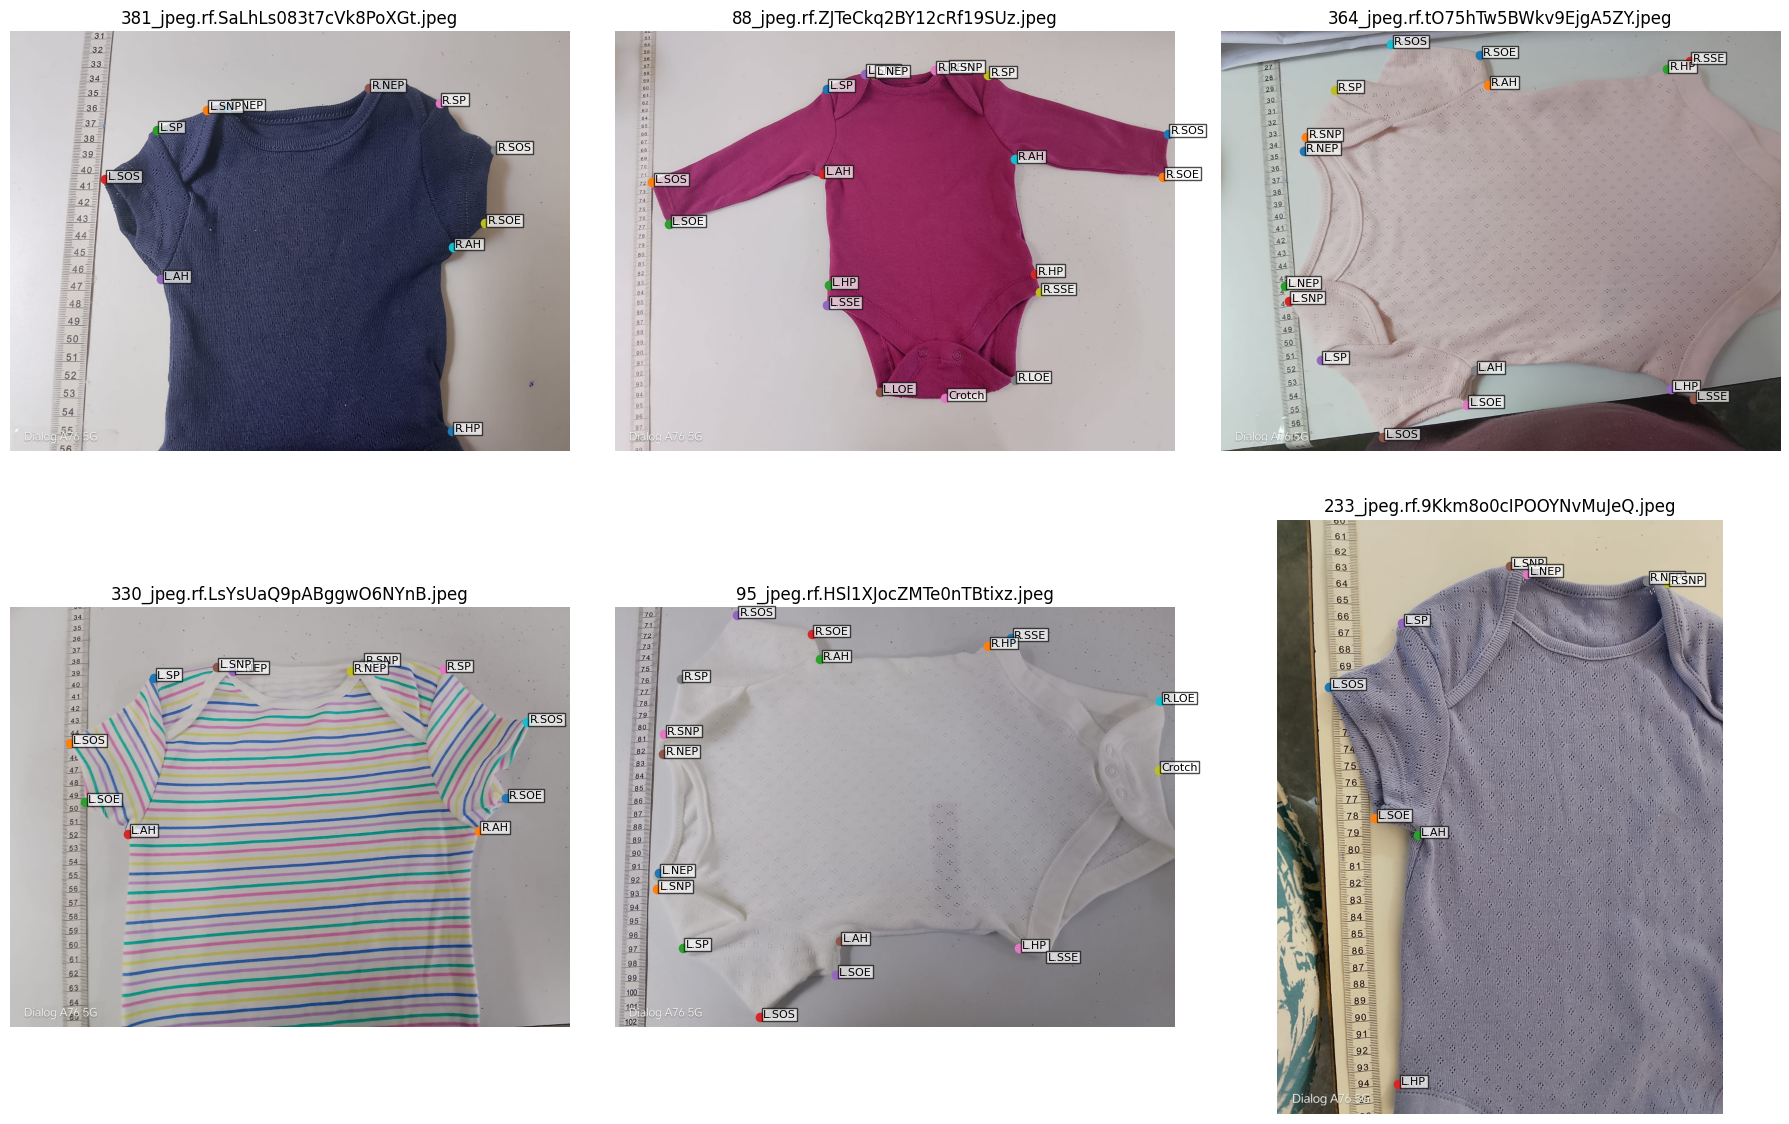

In [4]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import random
import matplotlib.pyplot as plt

dataset = Path("/content/gmas_keypoint")
image_dir = dataset / "train/images"
label_dir = dataset / "train/labels"

names = [
    "Crotch", "L.AH", "L.FBP", "L.FFP", "L.HP", "L.LOE",
    "L.NEP", "L.SNP", "L.SOE", "L.SOS", "L.SP", "L.SSE",
    "R.AH", "R.FBP", "R.FFP", "R.HP", "R.LOE", "R.NEP",
    "R.SNP", "R.SOE", "R.SOS", "R.SP", "R.SSE"
]

image_files = list(image_dir.glob("*"))
selected = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, image_path in zip(axes, selected):

    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    ax.imshow(img)

    label_path = label_dir / f"{image_path.stem}.txt"

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        for line in lines:
            parts = line.split()

            class_id = int(parts[0])
            x = float(parts[1]) * w
            y = float(parts[2]) * h

            ax.scatter(x, y, s=35)

            ax.text(
                x + 8,
                y,
                names[class_id],
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.7, pad=1)
            )

    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()